# MNIST: 10 Specialists (ResNet18) -> 1 Generalist (ResNet50)

**Big idea (beginner version)**

1. **Specialists** – we train 10 small ResNet18 models. Model `d` only answers one question:
   *"Is this image the digit `d`, or NOT `d`?"* (so it has **2 outputs / heads**: `not d` and `d`).
2. **Generalist** – one bigger ResNet50 with **10 outputs**. It sees an image with **two digits stacked side by side**
   (for example a `7` next to a `9`) and must switch on the outputs for `7` and `9`.
3. **Transfer learning** – the generalist *learns from the specialists*.
   ResNet18 and ResNet50 have different shapes, so we cannot copy weights directly.
   Instead we use **knowledge distillation**: the specialists act as teachers and tell the generalist
   *"I see a 7 on the left"*, *"I see a 9 on the right"*. The generalist learns from these hints **plus** the true labels.

```
 [7][9]  ---> ResNet50 (generalist) ---> 10 numbers (one per digit) ---> 7 and 9 are ON
   |
   +--> left half [7]  --> 10 specialists --> "digit 7 = 0.99"
   +--> right half [9] --> 10 specialists --> "digit 9 = 0.98"     (teacher hints)
```

## 0. Install & imports

In [1]:
# Uncomment if you do not have the libraries yet:
!pip install torch torchvision matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

## 1. Settings

Change these numbers to make training faster (smaller) or better (bigger).
If you have no GPU, keep the numbers small first!

In [3]:
ALPHA = 1.0   # how much the generalist listens to specialists (0 = ignore them, only true labels)

In [4]:
SEED = 42

# Use GPU if available (much faster), otherwise CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():   # Apple Silicon
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("Using device:", DEVICE)

BATCH_SIZE = 128

# --- Specialists ---
SPEC_EPOCHS = 2            # how many passes over the data for each specialist
SPEC_TRAIN_SIZE = 20000    # number of MNIST images used per specialist (None = all 60000)

# --- Generalist ---
GEN_EPOCHS = 3
STACK_TRAIN_SAMPLES = 30000   # how many random stacked pairs to create for training
STACK_TEST_SAMPLES = 5000     # how many random stacked pairs to create for testing

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


## 2. Load MNIST

MNIST = 70,000 grey images (28x28 pixels) of handwritten digits 0-9.
`Normalize` just makes pixel values centred around 0, which helps neural networks learn.

Train images: 60000 | Test images: 10000


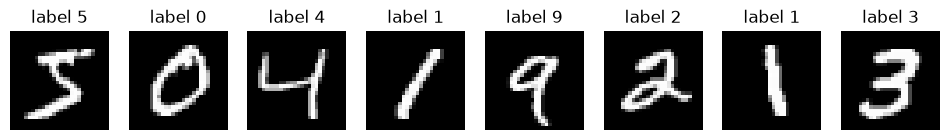

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),                       # image -> tensor with values 0..1
    transforms.Normalize((0.1307,), (0.3081,)),  # standard MNIST mean / std
])

train_full = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_full  = datasets.MNIST("./data", train=False, download=True, transform=transform)

print("Train images:", len(train_full), "| Test images:", len(test_full))

# Look at a few examples
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    img, label = train_full[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"label {label}")
    ax.axis("off")
plt.show()

## 3. Build the models

We modify ResNet a little because MNIST images are tiny and have **1 colour channel** (grey), not 3:
- `conv1`: accept 1 channel and use a small 3x3 filter (the original 7x7 is too big for 28x28 images).
- `fc` (the last layer = the "head"): set how many outputs we want.

In [6]:
def make_resnet18(num_outputs=2):
    # Specialist: ResNet18 with a 2-output head -> [not_d, d]
    model = models.resnet18(weights=None)   # weights=None -> start from random weights
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_outputs)
    return model

In [7]:
def make_resnet50(num_outputs=10):
    # Generalist: ResNet50 with a 10-output head -> one output per digit 0..9
    model = models.resnet50(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_outputs)
    return model

## 4. Specialist datasets ("digit d" vs "not d")

For specialist `d` we relabel MNIST:
- label **1** if the image is digit `d`
- label **0** otherwise

Example for specialist 3: an image of `3` -> 1, an image of `8` -> 0.

In [8]:
class BinaryMNIST(Dataset):
    # Wraps MNIST and changes the label to: 1 if label == digit else 0
    def __init__(self, base_dataset, digit):
        self.base = base_dataset
        self.digit = digit

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        return img, int(label == self.digit)

In [9]:
# Use a random subset of the training data (faster). Set SPEC_TRAIN_SIZE=None for everything.
if SPEC_TRAIN_SIZE is None:
    spec_train_base = train_full
else:
    idx = np.random.permutation(len(train_full))[:SPEC_TRAIN_SIZE]
    spec_train_base = Subset(train_full, idx.tolist())

## 5. Train the 10 specialists

Problem: only ~10% of images are "digit d", 90% are "not d". A lazy model could answer "not d" every time
and be 90% correct! To avoid this we give the positive class a **bigger weight** in the loss
(mistakes on the rare class cost more).

In [10]:
def train_specialist(digit):
    model = make_resnet18(num_outputs=2).to(DEVICE)

    train_loader = DataLoader(BinaryMNIST(spec_train_base, digit),
                              batch_size=BATCH_SIZE, shuffle=True)

    # class 0 = "not d" (weight 1), class 1 = "d" (weight 9 because it is ~9x rarer)
    class_weights = torch.tensor([1.0, 9.0]).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(SPEC_EPOCHS):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()              # 1) clear old gradients
            outputs = model(images)            # 2) forward pass
            loss = criterion(outputs, labels)  # 3) how wrong are we?
            loss.backward()                    # 4) compute gradients
            optimizer.step()                   # 5) update weights

            total_loss += loss.item()
        print(f"  specialist {digit} | epoch {epoch+1}/{SPEC_EPOCHS} | loss {total_loss/len(train_loader):.4f}")

    model.eval()
    torch.save(model.state_dict(), f"specialist_{digit}.pt")
    return model

In [11]:
specialists = []
for d in range(10):
    print(f"=== Training specialist for digit {d} ===")
    specialists.append(train_specialist(d))

=== Training specialist for digit 0 ===
  specialist 0 | epoch 1/2 | loss 0.0517
  specialist 0 | epoch 2/2 | loss 0.0184
=== Training specialist for digit 1 ===
  specialist 1 | epoch 1/2 | loss 0.0468
  specialist 1 | epoch 2/2 | loss 0.0157
=== Training specialist for digit 2 ===
  specialist 2 | epoch 1/2 | loss 0.0891
  specialist 2 | epoch 2/2 | loss 0.0333
=== Training specialist for digit 3 ===
  specialist 3 | epoch 1/2 | loss 0.0910
  specialist 3 | epoch 2/2 | loss 0.0324
=== Training specialist for digit 4 ===
  specialist 4 | epoch 1/2 | loss 0.0752
  specialist 4 | epoch 2/2 | loss 0.0310
=== Training specialist for digit 5 ===
  specialist 5 | epoch 1/2 | loss 0.0728
  specialist 5 | epoch 2/2 | loss 0.0372
=== Training specialist for digit 6 ===
  specialist 6 | epoch 1/2 | loss 0.0560
  specialist 6 | epoch 2/2 | loss 0.0204
=== Training specialist for digit 7 ===
  specialist 7 | epoch 1/2 | loss 0.0731
  specialist 7 | epoch 2/2 | loss 0.0307
=== Training specialist 

## 6. Check the specialists on the test set

- **accuracy**: overall correct answers
- **recall on d**: out of all real `d` images, how many did the specialist find?

In [12]:
@torch.no_grad()
def evaluate_specialist(model, digit):
    loader = DataLoader(BinaryMNIST(test_full, digit), batch_size=256)
    correct, total, pos_correct, pos_total = 0, 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
        pos_mask = labels == 1
        pos_correct += (preds[pos_mask] == 1).sum().item()
        pos_total += pos_mask.sum().item()
    return correct / total, pos_correct / max(pos_total, 1)

In [13]:
for d, m in enumerate(specialists):
    acc, recall = evaluate_specialist(m, d)
    print(f"Specialist {d}: accuracy {acc*100:.2f}% | recall on digit {d}: {recall*100:.2f}%")

Specialist 0: accuracy 98.09% | recall on digit 0: 99.80%
Specialist 1: accuracy 99.84% | recall on digit 1: 99.30%
Specialist 2: accuracy 99.57% | recall on digit 2: 96.90%
Specialist 3: accuracy 99.76% | recall on digit 3: 99.01%
Specialist 4: accuracy 99.38% | recall on digit 4: 98.47%
Specialist 5: accuracy 99.11% | recall on digit 5: 90.58%
Specialist 6: accuracy 99.34% | recall on digit 6: 98.43%
Specialist 7: accuracy 98.98% | recall on digit 7: 98.83%
Specialist 8: accuracy 99.18% | recall on digit 8: 96.61%
Specialist 9: accuracy 99.36% | recall on digit 9: 95.64%


### Bonus sanity check: do the 10 specialists work as a team?

Each specialist gives a probability "I think it is my digit". We pick the specialist with the highest probability.
If the team is good, this behaves like a normal 10-class digit classifier.

In [14]:
@torch.no_grad()
def specialists_predict(images):
    # images: (B, 1, 28, 28) -> returns (B, 10): probability that each digit is present
    probs = []
    for m in specialists:
        m.eval()
        p = F.softmax(m(images), dim=1)[:, 1]   # index 1 = "it is digit d"
        probs.append(p)
    return torch.stack(probs, dim=1)

In [15]:
loader = DataLoader(test_full, batch_size=256)
correct = 0
for images, labels in loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    correct += (specialists_predict(images).argmax(dim=1) == labels).sum().item()
print(f"Team of specialists, 10-class accuracy: {correct/len(test_full)*100:.2f}%")

Team of specialists, 10-class accuracy: 97.91%


## 7. Stacked two-digit dataset (for the generalist)

We glue two random MNIST images **side by side** -> one image of size 28 x 56.

The label is a vector of 10 numbers (**multi-hot**):
- `[0,0,0,0,0,0,0,1,0,1]` means "digit 7 and digit 9 are present".
- If both digits are the same (e.g. 4 and 4) only one position is 1.

In [16]:
class StackedMNIST(Dataset):
    def __init__(self, base_dataset, n_samples, seed):
        self.base = base_dataset
        rng = np.random.RandomState(seed)
        # Pick which two MNIST images to overlay for every sample (fixed once, so it is repeatable)
        self.left_idx  = rng.randint(0, len(base_dataset), n_samples)
        self.right_idx = rng.randint(0, len(base_dataset), n_samples)

    def __len__(self):
        return len(self.left_idx)

    def __getitem__(self, i):
        img_a, lab_a = self.base[int(self.left_idx[i])]
        img_b, lab_b = self.base[int(self.right_idx[i])]

        # Superimpose the two digits on the same canvas -> (1, 28, 28)
        # max keeps both strokes at full brightness where they cross
        stacked = torch.maximum(img_a, img_b)

        target = torch.zeros(10)                     # multi-hot label
        target[lab_a] = 1.0
        target[lab_b] = 1.0
        return stacked, target, torch.tensor([lab_a, lab_b]), img_a, img_b
        # return stacked, target, torch.tensor([lab_a, lab_b])

In [17]:
stack_train = StackedMNIST(train_full, STACK_TRAIN_SAMPLES, seed=1)
stack_test  = StackedMNIST(test_full,  STACK_TEST_SAMPLES,  seed=2)

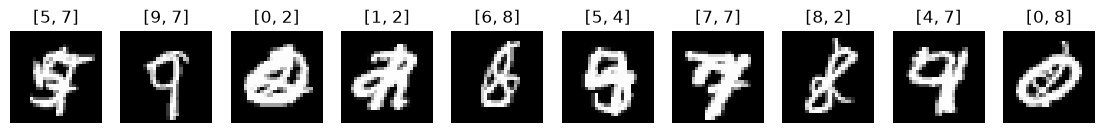

In [18]:
# Look at random examples (re-run the cell to see new ones)
idxs = random.sample(range(len(stack_train)), 10)

fig, axes = plt.subplots(1, 10, figsize=(14, 2.5))
for idx, ax in zip(idxs, axes):
    x, target, digits, img_a, img_b = stack_train[idx]
    ax.imshow(x.squeeze(), cmap="gray")
    ax.set_title(f"{digits.tolist()}")
    ax.axis("off")
plt.show()

## 8. Transfer learning: specialists teach the generalist

For every stacked image during training:
1. Cut it into **left half** and **right half** (each is a normal 28x28 digit).
2. Ask all 10 specialists about each half -> probabilities like `[0.01, 0.02, ..., 0.99, ...]`.
3. Combine the two halves with `max`: digit `d` is "present" if the left **or** right half looks like `d`.
   This is the **teacher hint** (a "soft label").
4. The generalist only sees the **whole stacked image** (it must learn to find both digits by itself).

**Loss = loss on true labels + ALPHA x loss on teacher hints.**

In [19]:
@torch.no_grad()
def teacher_targets(stacked_images):
    # stacked_images: (B, 1, 28, 56) -> teacher hint (B, 10)
    left  = stacked_images[:, :, :, :28]    # left digit
    right = stacked_images[:, :, :, 28:]    # right digit
    p_left  = specialists_predict(left)
    p_right = specialists_predict(right)
    return torch.maximum(p_left, p_right)   # digit present if EITHER half looks like it

In [20]:

generalist = make_resnet50(num_outputs=10).to(DEVICE)

train_loader = DataLoader(stack_train, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(stack_test,  batch_size=BATCH_SIZE)

# BCEWithLogitsLoss = "each of the 10 outputs is its own yes/no question" (multi-label)
bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(generalist.parameters(), lr=1e-3)

## 9. Train the generalist

In [ ]:
def train_generalist(model,saveFile):
    for epoch in range(GEN_EPOCHS):
        model.train()
        run_hard, run_soft = 0.0, 0.0

        # for images, targets, _ in train_loader:
        for images, targets, _, img_a, img_b in train_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)

            logits = model(images)                      # 10 raw scores
            loss_hard = bce(logits, targets)            # learn from the TRUE labels

            if ALPHA > 0:
                # soft = teacher_targets(images)        # hints from the specialists
                soft = torch.maximum(specialists_predict(img_a.to(DEVICE)), specialists_predict(img_b.to(DEVICE)))
                loss_soft = bce(logits, soft)           # learn from the TEACHERS
            else:
                loss_soft = torch.tensor(0.0, device=DEVICE)

            loss = loss_hard + ALPHA * loss_soft

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            run_hard += loss_hard.item()
            run_soft += loss_soft.item()

        n = len(train_loader)
        print(f"Epoch {epoch+1}/{GEN_EPOCHS} | true-label loss {run_hard/n:.4f} | teacher loss {run_soft/n:.4f}")

    torch.save(model.state_dict(), saveFile)

In [22]:
train_generalist(model=generalist, saveFile="generalist_resnet50.pt")

Epoch 1/3 | true-label loss 0.1959 | teacher loss 0.2149
Epoch 2/3 | true-label loss 0.0965 | teacher loss 0.1241
Epoch 3/3 | true-label loss 0.0723 | teacher loss 0.1036


## 10. Evaluate the generalist

A digit is predicted "present" when its output probability is above 0.5.
- **Exact match**: the predicted set of digits equals the true set (e.g. exactly {7, 9}).
- **Per-digit accuracy**: how often each single yes/no answer is right.

In [ ]:
@torch.no_grad()
def evaluate_generalist(model, loader):
    model.eval()
    exact, total = 0, 0
    per_digit_correct = torch.zeros(10)
    for images, targets, *_ in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        preds = (torch.sigmoid(model(images)) > 0.5).float()

        exact += (preds == targets).all(dim=1).sum().item()
        per_digit_correct += (preds == targets).float().sum(dim=0).cpu()
        total += targets.size(0)

    print(f"Exact match (both digits found, nothing extra): {exact/total*100:.2f}%")
    for d in range(10):
        print(f"  digit {d} yes/no accuracy: {per_digit_correct[d].item()/total*100:.2f}%")

In [24]:
evaluate_generalist(model=generalist, loader=test_loader)

Exact match (both digits found, nothing extra): 75.88%
  digit 0 yes/no accuracy: 98.02%
  digit 1 yes/no accuracy: 97.04%
  digit 2 yes/no accuracy: 96.86%
  digit 3 yes/no accuracy: 95.24%
  digit 4 yes/no accuracy: 96.40%
  digit 5 yes/no accuracy: 96.58%
  digit 6 yes/no accuracy: 98.24%
  digit 7 yes/no accuracy: 95.94%
  digit 8 yes/no accuracy: 96.60%
  digit 9 yes/no accuracy: 94.78%


## 11. See predictions

In [25]:
@torch.no_grad()
def show_predictions(model, n=8):
    model.eval()
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 3))
    for ax in axes:
        i = random.randrange(len(stack_test))
        x, target, digits, img_a, img_b = stack_test[i]     # x is the overlaid (1, 28, 28) image

        probs = torch.sigmoid(model(x.unsqueeze(0).to(DEVICE)))[0].cpu()
        predicted = [d for d in range(10) if probs[d] > 0.5]
        true = sorted(set(digits.tolist()))

        ax.imshow(x.squeeze(), cmap="gray")
        ax.set_title(f"true {true}\npred {predicted}",
                     color="green" if predicted == true else "red")
        ax.axis("off")
    plt.show()

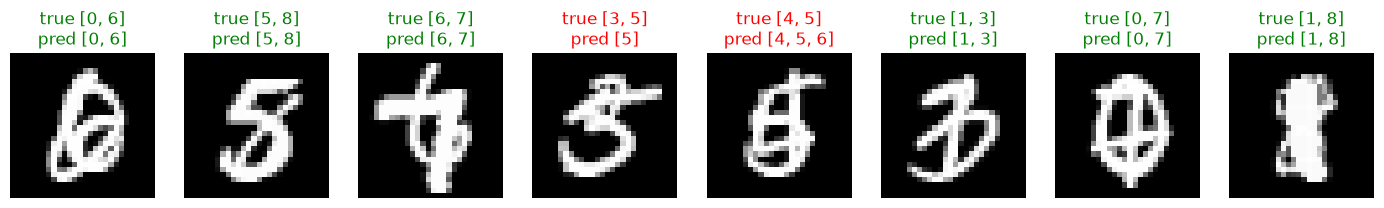

In [31]:
show_predictions(model=generalist)

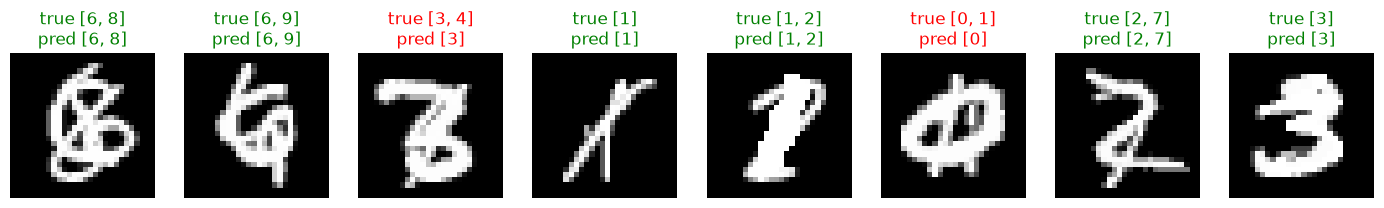

In [48]:
show_predictions(model=generalist)

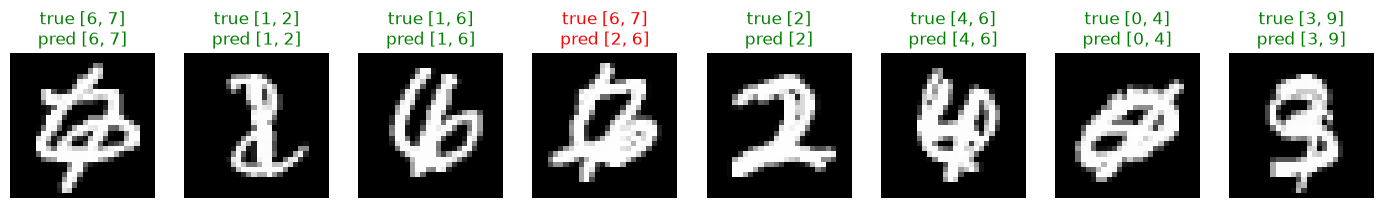

In [49]:
show_predictions(model=generalist)

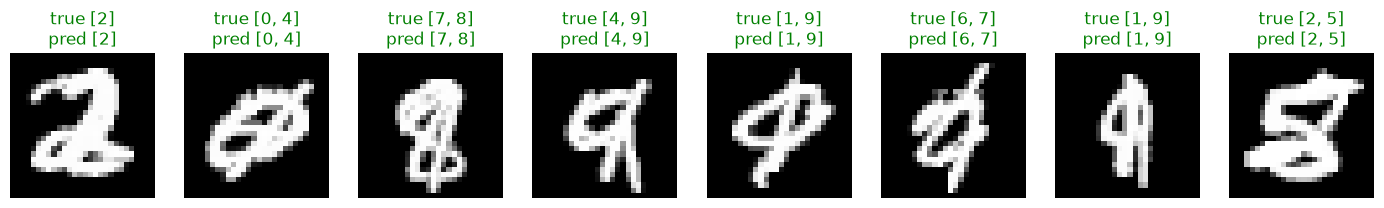

In [50]:
show_predictions(model=generalist)

## 12. Without teachers

In [35]:
ALPHA = 0.0
GEN_EPOCHS = 3

In [36]:
generalist_no_teacher = make_resnet50(num_outputs=10).to(DEVICE)

In [37]:
train_generalist(model=generalist_no_teacher, saveFile="generalist_resnet50_no_teacher.pt")

Epoch 1/3 | true-label loss 0.6939 | teacher loss 0.0000
Epoch 2/3 | true-label loss 0.6941 | teacher loss 0.0000
Epoch 3/3 | true-label loss 0.6941 | teacher loss 0.0000


In [38]:
evaluate_generalist(model=generalist_no_teacher, loader=test_loader)

Exact match (both digits found, nothing extra): 0.16%
  digit 0 yes/no accuracy: 20.02%
  digit 1 yes/no accuracy: 50.00%
  digit 2 yes/no accuracy: 76.90%
  digit 3 yes/no accuracy: 30.02%
  digit 4 yes/no accuracy: 48.28%
  digit 5 yes/no accuracy: 75.62%
  digit 6 yes/no accuracy: 78.56%
  digit 7 yes/no accuracy: 37.96%
  digit 8 yes/no accuracy: 80.16%
  digit 9 yes/no accuracy: 44.80%


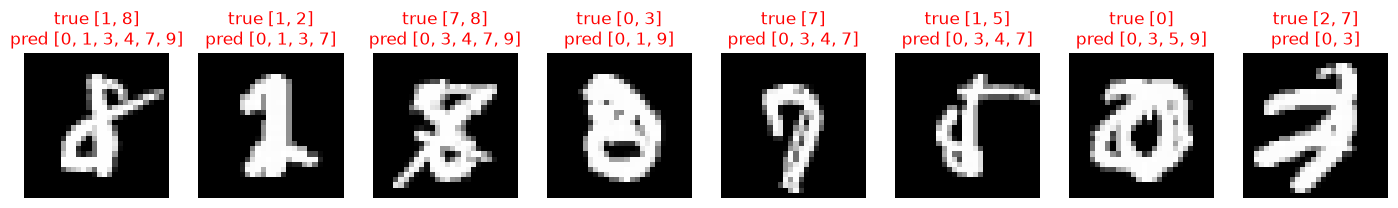

In [47]:
show_predictions(model=generalist_no_teacher)

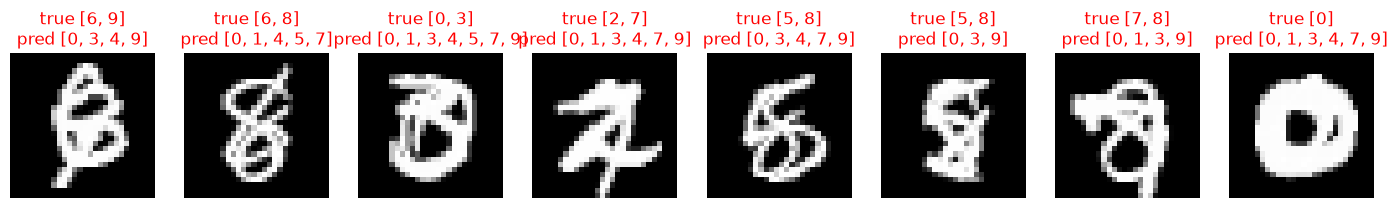

In [51]:
show_predictions(model=generalist_no_teacher)

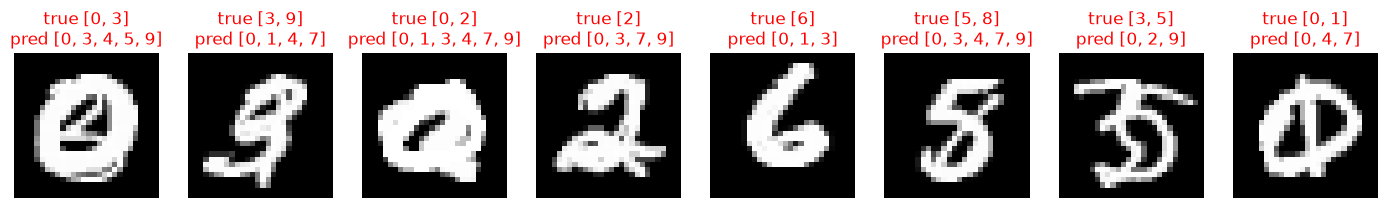

In [52]:
show_predictions(model=generalist_no_teacher)

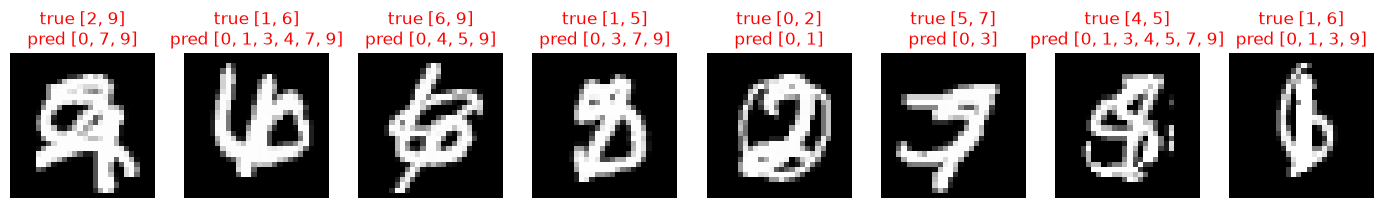

In [53]:
show_predictions(model=generalist_no_teacher)

## 13. Without teacher increase epoch

In [ ]:
ALPHA = 0.0
GEN_EPOCHS = 10

In [55]:
train_generalist(model=generalist_no_teacher, saveFile="generalist_resnet50_no_teacher_plus.pt")

Epoch 1/10 | true-label loss 0.6938 | teacher loss 0.0000
Epoch 2/10 | true-label loss 0.6937 | teacher loss 0.0000
Epoch 3/10 | true-label loss 0.6938 | teacher loss 0.0000
Epoch 4/10 | true-label loss 0.6940 | teacher loss 0.0000
Epoch 5/10 | true-label loss 0.6941 | teacher loss 0.0000
Epoch 6/10 | true-label loss 0.6941 | teacher loss 0.0000
Epoch 7/10 | true-label loss 0.6941 | teacher loss 0.0000
Epoch 8/10 | true-label loss 0.6943 | teacher loss 0.0000
Epoch 9/10 | true-label loss 0.6941 | teacher loss 0.0000
Epoch 10/10 | true-label loss 0.6945 | teacher loss 0.0000


In [56]:
evaluate_generalist(model=generalist_no_teacher, loader=test_loader)

Exact match (both digits found, nothing extra): 0.04%
  digit 0 yes/no accuracy: 19.84%
  digit 1 yes/no accuracy: 49.52%
  digit 2 yes/no accuracy: 76.76%
  digit 3 yes/no accuracy: 30.82%
  digit 4 yes/no accuracy: 47.98%
  digit 5 yes/no accuracy: 76.04%
  digit 6 yes/no accuracy: 78.96%
  digit 7 yes/no accuracy: 38.44%
  digit 8 yes/no accuracy: 80.04%
  digit 9 yes/no accuracy: 44.94%


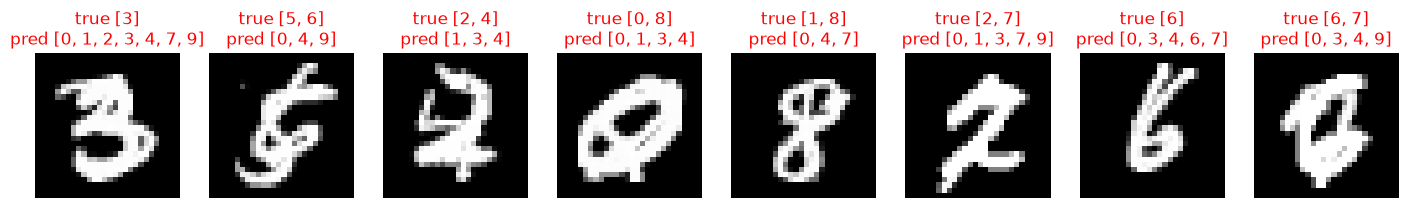

In [57]:
show_predictions(model=generalist_no_teacher)

## Summary / ideas to try

| Step | What happens |
|------|--------------|
| Specialists | 10 x ResNet18, each answers "digit d or not d" |
| Stacked data | two random MNIST digits side by side, label = 10-number multi-hot vector |
| Transfer | specialists give soft hints for left and right half -> generalist learns from them (distillation) |
| Generalist | ResNet50, 10 sigmoid outputs, threshold 0.5 |

**Experiments:**
- Set `ALPHA = 0` and compare: does the generalist do worse without the teachers?
- Increase epochs / dataset sizes for higher accuracy.
- Stack 3 digits (make the image 28 x 84 and update `teacher_targets`).